In [57]:
#distribution of dissociation
import matplotlib.pyplot as plt
import numpy as np
import h5py
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halos_central_12.hdf5",'r')
m50=np.array(f["m50"])
f_sat=np.array(f["sat_fraction"])
com_dm=np.asarray(f['com_dm'])
com_gas=np.asarray(f['com_g'])
com_s=np.asarray(f['com_s'])
M_dm=np.asarray(f['M_dm'])
M_g=np.asarray(f['M_g'])
M_s=np.asarray(f['M_s'])
r50=np.asarray(f['r50'])
print(np.histogram(com_dm,bins=10))
com_b=((M_s*com_s.T+M_g*com_gas.T)/(M_g+M_s)).T
f.close()
delta_com=com_b - com_dm
r_com=np.sqrt(np.sum(delta_com**2,axis=1))

f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800_NoCool/halos_central_12.hdf5",'r')
m50_ad=np.array(f["m50"])

com_dm_ad=np.asarray(f['com_dm'])
com_gas_ad=np.asarray(f['com_g'])
M_dm_ad=np.asarray(f['M_dm'])
M_g_ad=np.asarray(f['M_g'])
r50_ad=np.asarray(f['r50'])
print(np.histogram(com_dm,bins=10))

f.close()
delta_com_ad=com_gas_ad - com_dm_ad
r_com_ad=np.sqrt(np.sum(delta_com_ad**2,axis=1))

f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halo_properties.hdf5",'r')
dm=f["PartType1"]
g=f["PartType0"]



rdm=np.array(dm["r_dm"])
rgas=np.array(g["r_g"])

f.close()
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800_NoCool/halo_properties.hdf5",'r')
dm=f["PartType1"]
g=f["PartType0"]


rdm_ad=np.array(dm["r_dm"])
rgas_ad=np.array(g["r_g"])

f.close()
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halo_properties_stars.hdf5",'r')
rs=np.array(f["PartType2"]["r_s"])
f.close()
q0_dm=rdm/M_dm
q0_b=(rgas+rs)/(M_g+M_s)
S0=-(q0_b-q0_dm)/np.max([q0_b,q0_dm],axis=0)
q0_dm_ad=rdm_ad/M_dm_ad
q0_b_ad=(rgas_ad)/(M_g_ad)
S0_ad=-(q0_b_ad-q0_dm_ad)/np.max([q0_b_ad,q0_dm_ad],axis=0)
print(np.max([q0_b_ad,q0_dm_ad],axis=0).shape)

(array([1244191,  194055,   47009,    9605,    2237,     579,     132,
            38,      10,       2]), array([ -0.75280769,  14.70187236,  30.1565524 ,  45.61123244,
        61.06591248,  76.52059252,  91.97527256, 107.4299526 ,
       122.88463265, 138.33931269, 153.79399273]))
(array([1244191,  194055,   47009,    9605,    2237,     579,     132,
            38,      10,       2]), array([ -0.75280769,  14.70187236,  30.1565524 ,  45.61123244,
        61.06591248,  76.52059252,  91.97527256, 107.4299526 ,
       122.88463265, 138.33931269, 153.79399273]))
(585930,)


Text(0, 0.5, 'Counts')

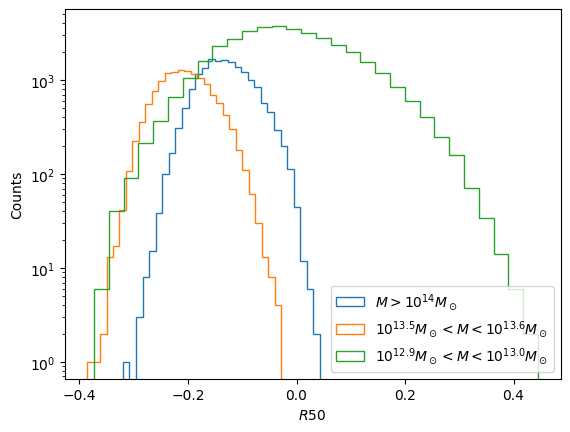

In [58]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.hist(S0[(r_com<5)*(m50>10**4)],histtype='step',label=r'$M>10^{14}M_\odot$',bins=30)
ax.hist(S0[(r_com<5)*(m50>10**3.5)*((m50<10**3.6))],histtype='step',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$',bins=30)
ax.hist(S0[(r_com<5)*(m50>10**2.9)*((m50<10**3.0))],histtype='step',label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$',bins=30)
ax.set_yscale('log')
ax.legend()
ax.set_xlabel(r"$R50$")
ax.set_ylabel(r"Counts")

Text(0, 0.5, 'Counts')

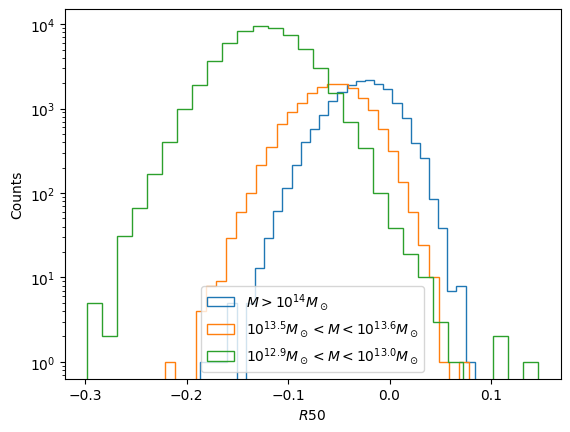

In [59]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.hist(S0_ad[(r_com_ad<5)*(m50_ad>10**4)],histtype='step',label=r'$M>10^{14}M_\odot$',bins=30)
ax.hist(S0_ad[(r_com_ad<5)*(m50_ad>10**3.5)*((m50_ad<10**3.6))],histtype='step',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$',bins=30)
ax.hist(S0_ad[(r_com_ad<5)*(m50_ad>10**2.9)*((m50_ad<10**3.0))],histtype='step',label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$',bins=30)
ax.set_yscale('log')
ax.legend()
ax.set_xlabel(r"$R50$")
ax.set_ylabel(r"Counts")

(array([7141, 7654, 1722,  396,   86,   18,    2,    0,    0,    1]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


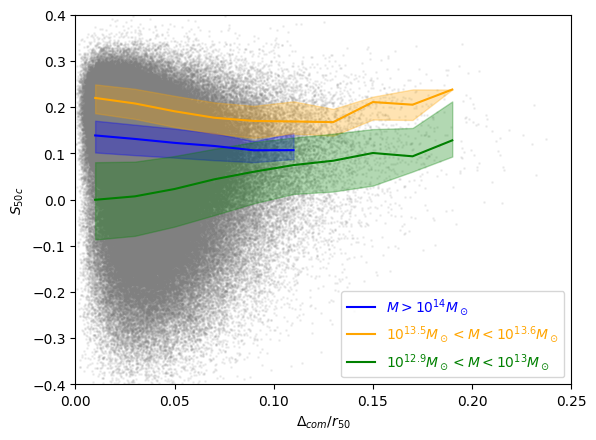

In [52]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)


r_com=np.sqrt(np.sum(delta_com**2,axis=1))
ax.scatter((r_com/r50)[(r_com<5)],S0[(r_com<5)],s=1,alpha=0.1,color="gray")
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')

bins=np.linspace(0,0.2,11)
bin=(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**4)],bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**4)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0[(r_com<5)*(m50>10**4)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0[(r_com<5)*(m50>10**4)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0[(r_com<5)*(m50>10**4)][bin_count==i],25)
ax.plot(bin[0:6],mean[0:6],color='blue',label=r'$M>10^{14}M_\odot$')
ax.fill_between(bin[0:6],per_25[0:6],per_75[0:6],color='blue',alpha=0.3)


bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],bins)
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],25)
ax.plot(bin,mean,color='orange',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='orange',alpha=0.3)

bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],bins)
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],25)
ax.plot(bin,mean,color='green',label=r'$10^{12.9}M_\odot<M<10^{13}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='green',alpha=0.3)

ax.legend(labelcolor='linecolor')
ax.set_xlabel(r"$\Delta_{com}/r_{50}$")
ax.set_ylabel(r"$S_{50c}$")
ax.set_ybound(-0.4,0.4)
ax.set_xbound(0,0.25)

(array([9937, 7147,    0,  526,    0,   24,    4,    0,    2,    1]), array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]))


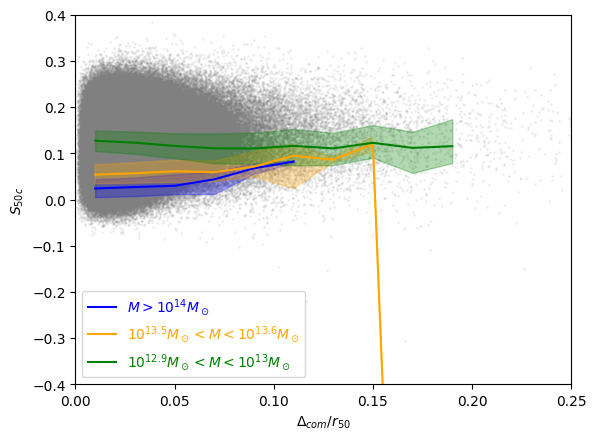

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)


ax.scatter((r_com_ad/r50_ad)[(r_com_ad<5)],S0_ad[(r_com_ad<5)],s=1,alpha=0.1,color="gray")
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')

bins=np.linspace(0,0.2,11)
bin=(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**4)],bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],25)
ax.plot(bin[0:6],mean[0:6],color='blue',label=r'$M>10^{14}M_\odot$')
ax.fill_between(bin[0:6],per_25[0:6],per_75[0:6],color='blue',alpha=0.3)


bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)],bins)
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],25)
ax.plot(bin,mean,color='orange',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='orange',alpha=0.3)

bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)],bins)
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],50)
    per_75[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],75)
    per_25[i-1]=np.percentile(S0_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],25)
ax.plot(bin,mean,color='green',label=r'$10^{12.9}M_\odot<M<10^{13}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='green',alpha=0.3)

ax.legend(labelcolor='linecolor')
ax.set_xlabel(r"$\Delta_{com}/r_{50}$")
ax.set_ylabel(r"$S_{50crit}$")
ax.set_ybound(-0.4,0.4)
ax.set_xbound(0,0.25)

(array([     1,  17116, 112111,  92877,  46002,  21500,   8889,   2928,
          643,     86]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


(3981071705534.969, 1258925411794166.2)

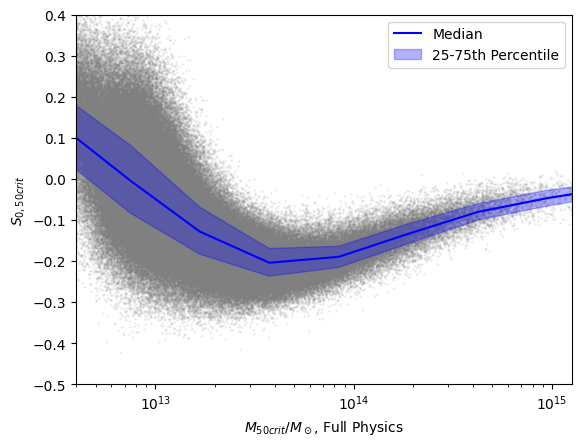

In [64]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(m50[r_com<10]*10**10,S0[r_com<10],s=1,alpha=0.1,color="grey")
bins=np.linspace(2,5.5,11)

bin=10**(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize(m50[r_com<10],10**bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
 
    mean[i-1]=np.percentile(S0[r_com<10][bin_count==i],50)
    per_75[i-1]=np.percentile(S0[r_com<10][bin_count==i],75)
    per_25[i-1]=np.percentile(S0[r_com<10][bin_count==i],25)
ax.plot(bin*10**10,mean,color='blue',label='Median')
ax.fill_between(bin*10**10,per_25,per_75,color='blue',alpha=0.3,label='25-75th Percentile')
ax.set_xscale('log')



ax.legend()
ax.set_xlabel(r"$M_{50crit}/M_\odot$, Full Physics")
ax.set_ylabel(r"$S_{0,50crit}$")
ax.set_ylim(-0.5,0.4)
ax.set_xlim(10**12.6,10**15.1)

(array([     3, 138965, 239622, 116490,  54506,  23409,   9205,   2961,
          641,     86]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


(-0.5, 0.4)

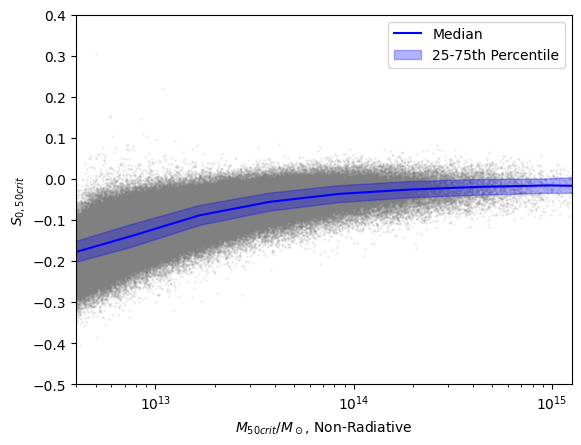

In [65]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(m50_ad[r_com_ad<10]*10**10,S0_ad[r_com_ad<10],s=1,alpha=0.1,color="gray")
bins=np.linspace(2,5.5,11)

bin=10**(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize(m50_ad[r_com_ad<10],10**bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
 
    mean[i-1]=np.percentile(S0_ad[r_com_ad<10][bin_count==i],50)
    per_75[i-1]=np.percentile(S0_ad[r_com_ad<10][bin_count==i],75)
    per_25[i-1]=np.percentile(S0_ad[r_com_ad<10][bin_count==i],25)
ax.plot(bin*10**10,mean,color='blue',label='Median')
ax.fill_between(bin*10**10,per_25,per_75,color='blue',alpha=0.3,label='25-75th Percentile')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r"$M_{50crit}/M_\odot$, Non-Radiative")
ax.set_ylabel(r"$S_{0,50crit}$")
ax.set_xlim(10**12.6,10**15.1)
ax.set_ylim(-0.5,0.4)